<a href="https://colab.research.google.com/github/vishesh-banna0/Concurrent-Programming-Lab/blob/main/CP_LAB_25_03_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📤 Upload an image file (.jpg/.png)


Saving image.jpg to image.jpg
✅ Uploaded: image.jpg
✅ Image loaded successfully
🚀 CUDA histogram computed


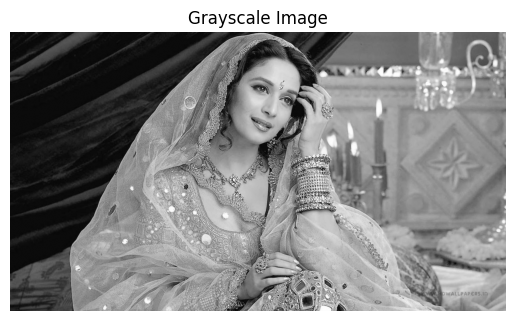

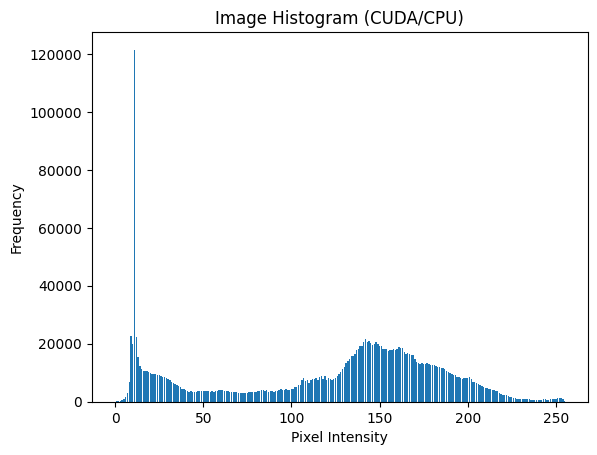

In [2]:
# ==============================
# INSTALL REQUIRED LIBRARIES
# ==============================
!pip install numba pillow matplotlib

# ==============================
# IMPORTS
# ==============================
import numpy as np
from numba import cuda
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
import io

# ==============================
# CUDA KERNEL
# ==============================
@cuda.jit
def histogram_kernel(image, hist):
    i = cuda.grid(1)

    if i < image.size:
        pixel = image[i]
        cuda.atomic.add(hist, pixel, 1)


# ==============================
# CUDA HISTOGRAM FUNCTION
# ==============================
def compute_histogram_cuda(image_array):
    flat_image = image_array.flatten().astype(np.uint8)
    hist = np.zeros(256, dtype=np.int32)

    d_image = cuda.to_device(flat_image)
    d_hist = cuda.to_device(hist)

    threads_per_block = 256
    blocks_per_grid = (flat_image.size + threads_per_block - 1) // threads_per_block

    histogram_kernel[blocks_per_grid, threads_per_block](d_image, d_hist)

    return d_hist.copy_to_host()


# ==============================
# UPLOAD IMAGE
# ==============================
print("📤 Upload an image file (.jpg/.png)")
uploaded = files.upload()

# Get uploaded file
file_name = list(uploaded.keys())[0]
print(f"✅ Uploaded: {file_name}")

# ==============================
# LOAD IMAGE
# ==============================
try:
    image_bytes = uploaded[file_name]
    img = Image.open(io.BytesIO(image_bytes)).convert("L")
    img_array = np.array(img)
    print("✅ Image loaded successfully")
except Exception as e:
    print("❌ Error loading image:", e)
    raise

# ==============================
# COMPUTE HISTOGRAM
# ==============================
try:
    hist = compute_histogram_cuda(img_array)
    print("🚀 CUDA histogram computed")
except Exception as e:
    print("⚠️ CUDA not available, using CPU:", e)
    hist, _ = np.histogram(img_array, bins=256, range=(0, 256))

# ==============================
# PLOT RESULT
# ==============================
plt.figure()
plt.imshow(img_array, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

plt.figure()
plt.bar(range(256), hist)
plt.title("Image Histogram (CUDA/CPU)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

📤 Upload image


Saving image.jpg to image (1).jpg
🚀 CUDA Equalization Done


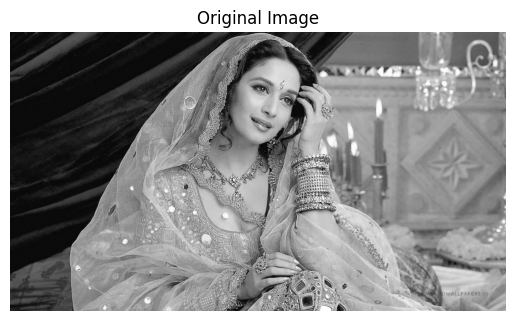

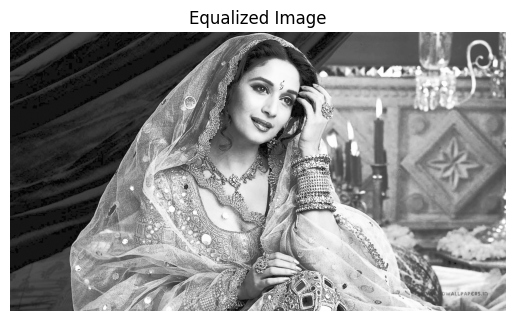

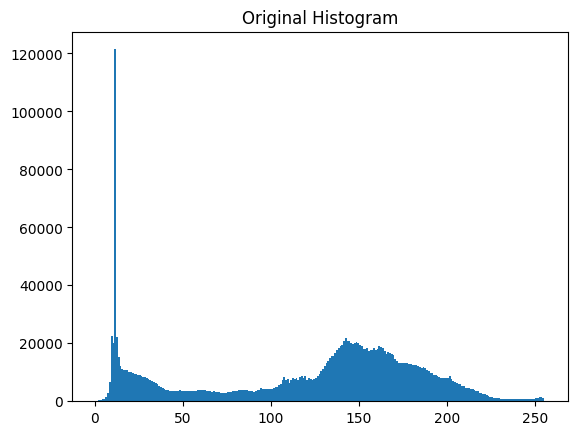

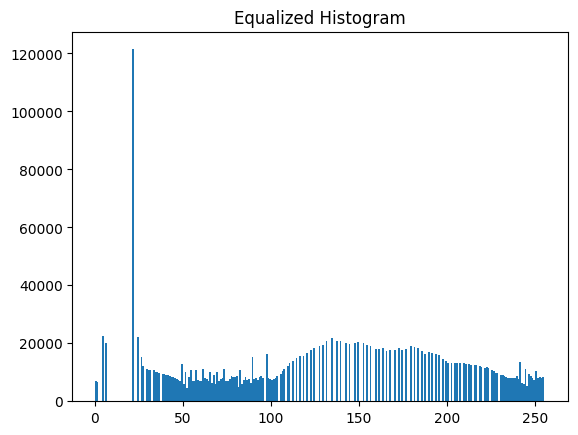

In [3]:
# ==============================
# INSTALL
# ==============================
!pip install numba pillow matplotlib

# ==============================
# IMPORTS
# ==============================
import numpy as np
from numba import cuda
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
import io

# ==============================
# CUDA KERNEL: HISTOGRAM
# ==============================
@cuda.jit
def histogram_kernel(image, hist):
    i = cuda.grid(1)
    if i < image.size:
        pixel = image[i]
        cuda.atomic.add(hist, pixel, 1)

# ==============================
# CUDA KERNEL: APPLY EQUALIZATION
# ==============================
@cuda.jit
def equalization_kernel(image, output, cdf):
    i = cuda.grid(1)
    if i < image.size:
        pixel = image[i]
        output[i] = cdf[pixel]

# ==============================
# CUDA HISTOGRAM
# ==============================
def compute_histogram_cuda(image_array):
    flat_image = image_array.flatten().astype(np.uint8)
    hist = np.zeros(256, dtype=np.int32)

    d_image = cuda.to_device(flat_image)
    d_hist = cuda.to_device(hist)

    threads_per_block = 256
    blocks_per_grid = (flat_image.size + threads_per_block - 1) // threads_per_block

    histogram_kernel[blocks_per_grid, threads_per_block](d_image, d_hist)

    return d_hist.copy_to_host(), flat_image

# ==============================
# HISTOGRAM EQUALIZATION
# ==============================
def histogram_equalization_cuda(image_array):
    # Step 1: Histogram
    hist, flat_image = compute_histogram_cuda(image_array)

    # Step 2: CDF (on CPU - acceptable)
    cdf = hist.cumsum()
    cdf_normalized = ((cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())).astype(np.uint8)

    # Step 3: Apply mapping on GPU
    output = np.zeros_like(flat_image, dtype=np.uint8)

    d_image = cuda.to_device(flat_image)
    d_output = cuda.to_device(output)
    d_cdf = cuda.to_device(cdf_normalized)

    threads_per_block = 256
    blocks_per_grid = (flat_image.size + threads_per_block - 1) // threads_per_block

    equalization_kernel[blocks_per_grid, threads_per_block](d_image, d_output, d_cdf)

    result = d_output.copy_to_host()

    return result.reshape(image_array.shape), hist

# ==============================
# UPLOAD IMAGE (COLAB)
# ==============================
print("📤 Upload image")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

img = Image.open(io.BytesIO(uploaded[file_name])).convert("L")
img_array = np.array(img)

# ==============================
# PROCESS
# ==============================
try:
    equalized_img, hist = histogram_equalization_cuda(img_array)
    print("🚀 CUDA Equalization Done")
except Exception as e:
    print("⚠️ CUDA failed, using CPU:", e)

    # CPU fallback
    hist, _ = np.histogram(img_array, bins=256, range=(0, 256))
    cdf = hist.cumsum()
    cdf_normalized = ((cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())).astype(np.uint8)
    equalized_img = cdf_normalized[img_array]

# ==============================
# PLOT RESULTS
# ==============================
plt.figure()
plt.imshow(img_array, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

plt.figure()
plt.imshow(equalized_img, cmap='gray')
plt.title("Equalized Image")
plt.axis('off')
plt.show()

plt.figure()
plt.hist(img_array.flatten(), bins=256, range=(0,256))
plt.title("Original Histogram")
plt.show()

plt.figure()
plt.hist(equalized_img.flatten(), bins=256, range=(0,256))
plt.title("Equalized Histogram")
plt.show()